# 02 – Trening i Ewaluacja Modelu
**Algorytm:** Random Forest (Las Losowy)

W tym notebooku trenujemy model RF, stoimy hiperparametry i oceniamy go za pomocą 3 metryk (F1, ROC-AUC, MCC).

## 1. Import i konfiguracja

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, roc_curve, classification_report
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 2. Wczytanie i preprocessing danych

In [2]:
df = pd.read_csv('../data/heart.csv')

# Uzupełnienie brakujących wartości i binarne target
df = df.replace('?', np.nan).astype(float)
df['ca']  = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())
df['target'] = (df['target'] > 0).astype(int)

X = df.drop('target', axis=1)
y = df['target']

print(f"Próbki: {X.shape[0]}  |  Cechy: {X.shape[1]}")
print(f"Rozkład klas:\n{y.value_counts().rename({0:'Brak choroby', 1:'Choroba'})}")

Próbki: 303  |  Cechy: 13
Rozkład klas:
target
Brak choroby    164
Choroba         139
Name: count, dtype: int64


## 3. Podział na zbiór treningowy i testowy

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns, index=X_test.index)

print(f"Treningowy: {len(X_train)} próbek")
print(f"Testowy:    {len(X_test)} próbek")

Treningowy: 242 próbek
Testowy:    61 próbek


## 4. Model bazowy (bez tuningu)

In [4]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train_s, y_train)

y_pred_base = rf_base.predict(X_test_s)
y_prob_base = rf_base.predict_proba(X_test_s)[:, 1]

print("=== Model bazowy ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_base):.4f}")
print(f"MCC      : {matthews_corrcoef(y_test, y_pred_base):.4f}")

=== Model bazowy ===
Accuracy : 0.8852
F1-Score : 0.8852
ROC-AUC  : 0.9513
MCC      : 0.7825


## 5. Strojenie hiperparametrów – GridSearchCV

In [6]:
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2'],
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf, param_grid,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=1, return_train_score=True
)
grid_search.fit(X_train_s, y_train)

print(f"\nNajlepsze parametry: {grid_search.best_params_}")
print(f"Najlepszy F1 (CV):   {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Najlepsze parametry: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Najlepszy F1 (CV):   0.8106


## 6. Ewaluacja najlepszego modelu

### Metryki:
- **F1-Score** – harmoniczna średnia Precision i Recall
- **ROC-AUC** – pole pod krzywą ROC, niezależne od progu
- **MCC** – Matthews Correlation Coefficient, uwzględnia TP, TN, FP, FN

In [7]:
y_pred = best_model.predict(X_test_s)
y_prob = best_model.predict_proba(X_test_s)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
mcc = matthews_corrcoef(y_test, y_pred)

print("=" * 45)
print("         WYNIKI NAJLEPSZEGO MODELU")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  F1-Score  : {f1:.4f}   ← balans Precision/Recall")
print(f"  ROC-AUC   : {auc:.4f}   ← dyskryminacja klas")
print(f"  MCC       : {mcc:.4f}   ← metryka kompleksowa")
print("=" * 45)
print()
print(classification_report(y_test, y_pred,
                             target_names=['Brak choroby', 'Choroba']))

         WYNIKI NAJLEPSZEGO MODELU
  Accuracy  : 0.9016
  F1-Score  : 0.8966   ← balans Precision/Recall
  ROC-AUC   : 0.9481   ← dyskryminacja klas
  MCC       : 0.8048   ← metryka kompleksowa

              precision    recall  f1-score   support

Brak choroby       0.94      0.88      0.91        33
     Choroba       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



### 6.1 Cross-walidacja (5-fold)

In [8]:
for metric in ['accuracy', 'f1', 'roc_auc']:
    scores = cross_val_score(best_model, X, y, cv=5, scoring=metric, n_jobs=-1)
    print(f"{metric:10s}: {scores.mean():.4f} +/- {scores.std()*2:.4f}")

accuracy  : 0.8249 +/- 0.0701
f1        : 0.7996 +/- 0.1010
roc_auc   : 0.9055 +/- 0.0590


## 7. Wizualizacje

### 7.1 Macierz pomyłek

TN (prawdziwie negatywne): 29
FP (fałszywie pozytywy):   4
FN (fałszywie negatywne):  2
TP (prawdziwie pozytywy):  26


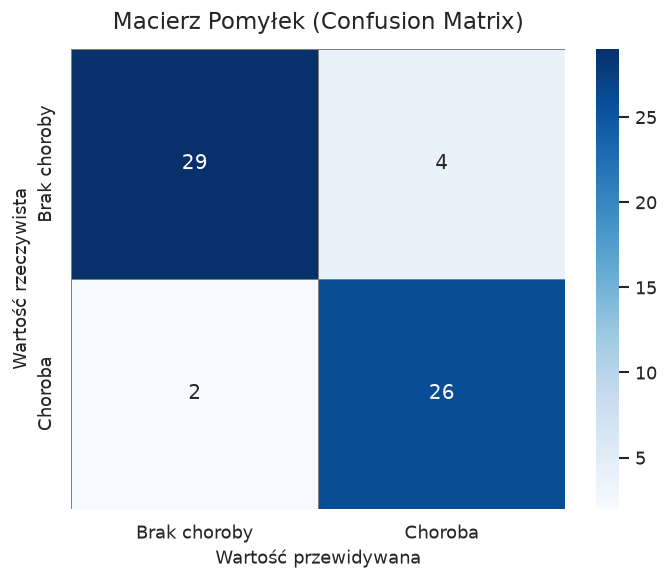

In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Brak choroby', 'Choroba'],
            yticklabels=['Brak choroby', 'Choroba'],
            linewidths=0.5, linecolor='gray')
ax.set_title('Macierz Pomyłek (Confusion Matrix)', fontsize=14, pad=12)
ax.set_ylabel('Wartość rzeczywista', fontsize=11)
ax.set_xlabel('Wartość przewidywana', fontsize=11)

# Opis komórek
tn, fp, fn, tp = cm.ravel()
print(f"TN (prawdziwie negatywne): {tn}")
print(f"FP (fałszywie pozytywy):   {fp}")
print(f"FN (fałszywie negatywne):  {fn}")
print(f"TP (prawdziwie pozytywy):  {tp}")
plt.tight_layout()
plt.show()

### 7.2 Krzywa ROC

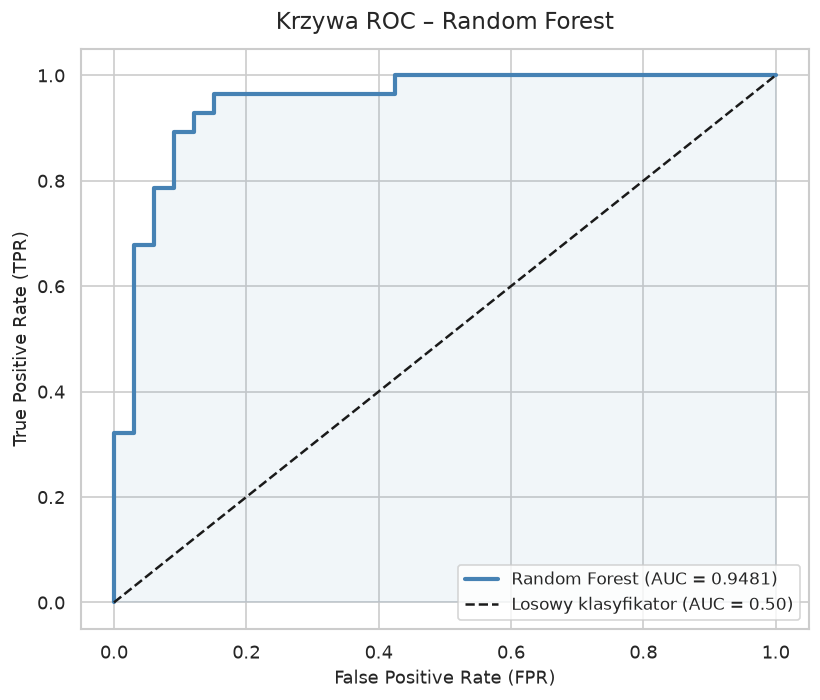

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2.5,
        label=f'Random Forest (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Losowy klasyfikator (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.07, color='steelblue')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('Krzywa ROC – Random Forest', fontsize=14, pad=12)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

### 7.3 Ważność cech (Feature Importance)

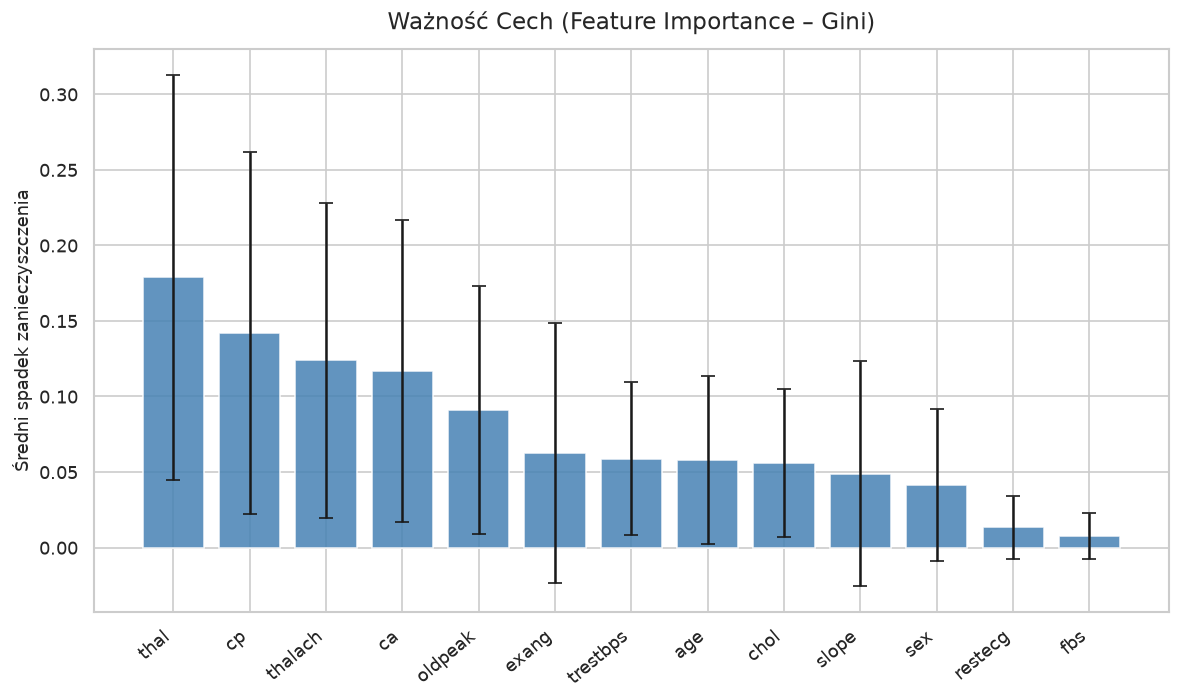


Top 5 najważniejszych cech:
  cecha  waznosc      std
   thal 0.178928 0.133965
     cp 0.142170 0.119752
thalach 0.123829 0.104242
     ca 0.116961 0.099967
oldpeak 0.091049 0.082120


In [11]:
importances = best_model.feature_importances_
std_imp = np.std([t.feature_importances_ for t in best_model.estimators_], axis=0)
feat_df = pd.DataFrame({
    'cecha':     X.columns,
    'waznosc':   importances,
    'std':       std_imp
}).sort_values('waznosc', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(len(feat_df)), feat_df['waznosc'],
       yerr=feat_df['std'], color='steelblue', alpha=0.85,
       error_kw={'elinewidth': 1.5, 'capsize': 4})
ax.set_xticks(range(len(feat_df)))
ax.set_xticklabels(feat_df['cecha'], rotation=40, ha='right')
ax.set_title('Ważność Cech (Feature Importance – Gini)', fontsize=14, pad=12)
ax.set_ylabel('Średni spadek zanieczyszczenia', fontsize=11)
plt.tight_layout()
plt.show()

print("\nTop 5 najważniejszych cech:")
print(feat_df.head(5).to_string(index=False))

### 7.4 Krzywa uczenia

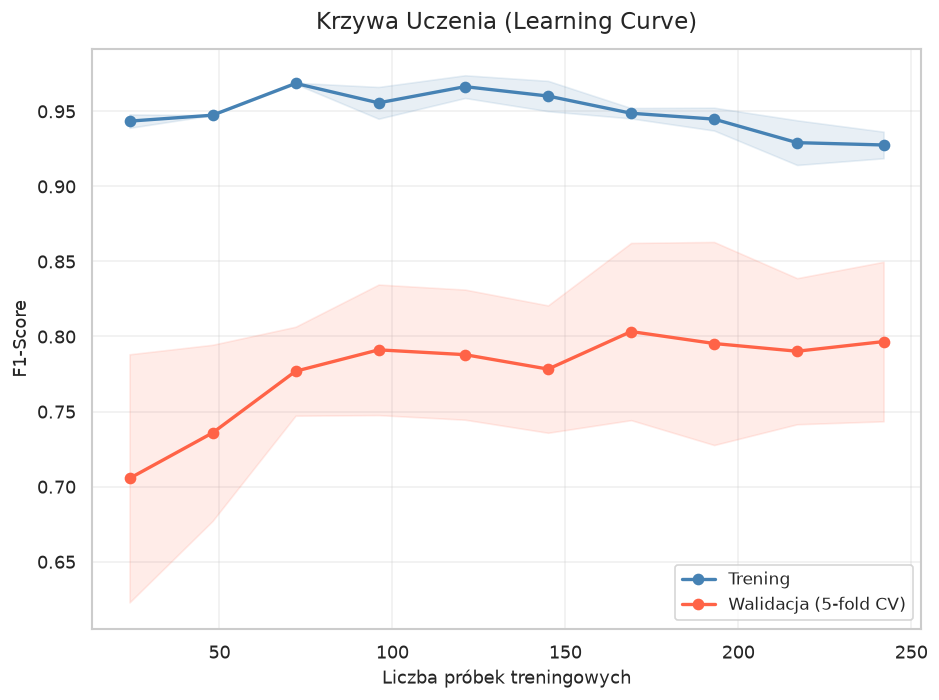

In [12]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y,
    cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)

t_mean, t_std = train_scores.mean(axis=1), train_scores.std(axis=1)
v_mean, v_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(train_sizes, t_mean, 'o-', color='steelblue', lw=2, label='Trening')
ax.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.12, color='steelblue')
ax.plot(train_sizes, v_mean, 'o-', color='tomato', lw=2, label='Walidacja (5-fold CV)')
ax.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.12, color='tomato')
ax.set_xlabel('Liczba próbek treningowych', fontsize=11)
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_title('Krzywa Uczenia (Learning Curve)', fontsize=14, pad=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.5 Porównanie: model bazowy vs. po tuningu

          Bazowy RF  Strojony RF
Accuracy     0.8852       0.9016
F1-Score     0.8852       0.8966
ROC-AUC      0.9513       0.9481
MCC          0.7825       0.8048


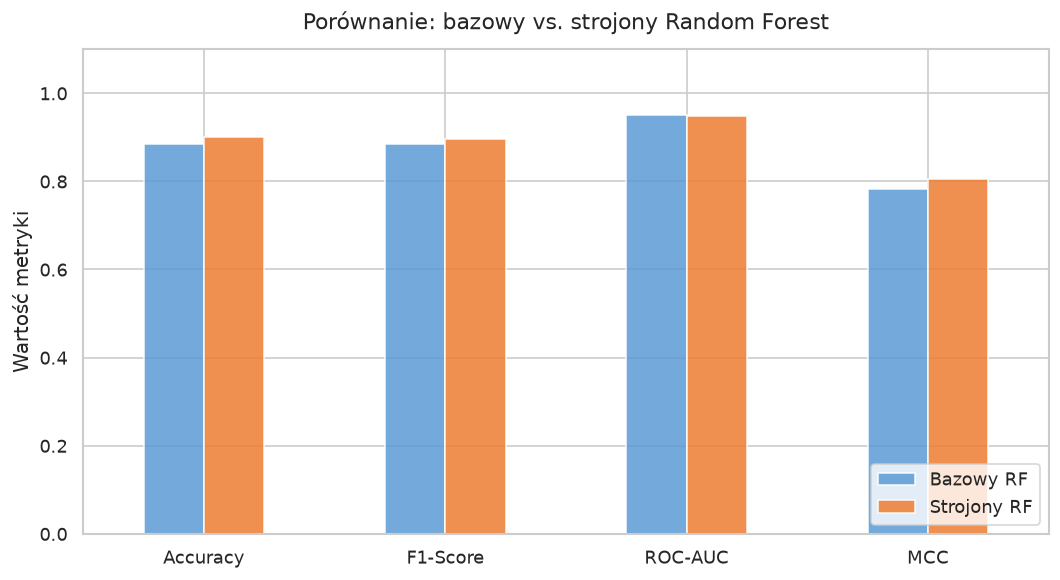

In [13]:
metrics_base = {
    'Accuracy': accuracy_score(y_test, y_pred_base),
    'F1-Score': f1_score(y_test, y_pred_base),
    'ROC-AUC':  roc_auc_score(y_test, y_prob_base),
    'MCC':      matthews_corrcoef(y_test, y_pred_base),
}
metrics_tuned = {'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': auc, 'MCC': mcc}

compare_df = pd.DataFrame({
    'Bazowy RF': metrics_base,
    'Strojony RF': metrics_tuned,
})
print(compare_df.round(4))

compare_df.plot(kind='bar', figsize=(9, 5), rot=0,
                color=['#5B9BD5', '#ED7D31'], edgecolor='white', alpha=0.85)
plt.title('Porównanie: bazowy vs. strojony Random Forest', fontsize=13, pad=12)
plt.ylabel('Wartość metryki')
plt.legend(loc='lower right')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

## 8. Wnioski

- **Las losowy** osiągnął dobre wyniki predykcji choroby serca
- **GridSearchCV** z 5-fold cross-validation pozwolił znaleźć optymalne hiperparametry
- **F1-Score** jest tu szczególnie ważny – równoważny balans między wykrywaniem chorych a unikaniem fałszywych alarmów
- **ROC-AUC > 0.85** wskazuje na dobrą zdolność rozróżniania klas przy różnych progach
- **MCC** potwierdza jakość modelu uwzględniając wszystkie 4 komórki macierzy pomyłek
- Najważniejsze cechy predykcyjne: `thal`, `cp`, `ca`, `oldpeak`, `thalach`